#  FASE 2.Selección de Variables

## Modelo jerárquico en cascada para cáncer

Este notebook adapta el flujo a una estrategia en dos etapas:

1. **Modelo 1**: clasifica cada muestra como `NORMAL` o `TUMOR`.
2. **Modelo 2**: si la muestra es tumoral, clasifica el tipo de cáncer entre `BRCA`, `COAD`, `KIRC`, `LUAD` y `PRAD`.

La lógica sigue una estructura en cascada para evitar mezclar tejido sano y tumoral en la segunda etapa. En ambos casos se usa:

- Split final agrupado por paciente (`participante`) para evitar fuga de información.
- Validación cruzada agrupada por paciente.
- Comparación de modelos, optimización de hiperparámetros y evaluación en un hold-out nunca visto.
- Guardado de los modelos, métricas y genes más relevantes.


> **Antes de ejecutar**: ajusta `DATA_PATH` en la siguiente celda a la ruta de tu archivo `dataset_clean.csv`.

In [1]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import (StratifiedGroupKFold, GroupShuffleSplit,
                                      cross_validate, RandomizedSearchCV)
from sklearn.metrics import (balanced_accuracy_score, f1_score, roc_auc_score,
                              cohen_kappa_score, make_scorer, classification_report,
                              confusion_matrix)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# --- Rutas ---
DATA_PATH = "dataset_clean.csv"          # <-- ajustar si es necesario
OUTPUT_DIR = "outputs_modelado_ml"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Los resultados se guardaran en:", os.path.abspath(OUTPUT_DIR))

palette_tipo = {"NORMAL": "#F97316", "TUMOR": "#1E3A8A"}
palette_cohorte = {"BRCA": "#1E3A8A", "COAD": "#059669",
                    "KIRC": "#7C3AED", "LUAD": "#DC2626", "PRAD": "#0891B2"}
palette_full = {"NORMAL": "#F97316", **palette_cohorte}

Los resultados se guardaran en: /content/outputs_modelado_ml


## 1. Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)

meta_cols = ["participante", "tipo", "cohorte"]
gene_cols = [c for c in df.columns if c not in meta_cols]

X = df[gene_cols].astype("float32").values
participante = df["participante"].values
tipo = df["tipo"].values
cohorte = df["cohorte"].values
gene_cols = np.array(gene_cols)

print("X:", X.shape)
print(pd.Series(tipo).value_counts())
print(pd.Series(cohorte[tipo == "tumor"]).value_counts())
print("Pacientes unicos:", len(np.unique(participante)))


X: (1680, 20531)
tumor     1344
normal     336
Name: count, dtype: int64
BRCA    448
KIRC    288
LUAD    236
PRAD    208
COAD    164
Name: count, dtype: int64
Pacientes unicos: 1360


## 2. Construccion de Variables objetivo


Se definen las dos variables objetivo del enfoque en cascada:

- **`binary_target`** (Modelo 1): `NORMAL` si `tipo == "normal"`, `TUMOR` si `tipo == "tumor"`.
- **`multiclass_target`** (Modelo 2): la `cohorte` (BRCA/COAD/KIRC/LUAD/PRAD), definida **solo para las muestras tumorales**.

Los grupos para toda la validación cruzada y los splits son el `participante` (paciente), para que ninguna muestra del mismo paciente quede repartida entre train y test en ninguna etapa.


In [3]:
# Variables objetivo jerárquicas
binary_target = np.where(tipo == "normal", "NORMAL", "TUMOR")
multiclass_target = np.where(tipo == "tumor", cohorte, np.nan)
groups = participante

print("X:", X.shape)
print("Modelo 1 ->", pd.Series(binary_target).value_counts().to_dict())
print("Modelo 2 ->", pd.Series(multiclass_target[~pd.isna(multiclass_target)]).value_counts().to_dict())

print("Pacientes únicos:", len(np.unique(groups)))

X: (1680, 20531)
Modelo 1 -> {'TUMOR': 1344, 'NORMAL': 336}
Modelo 2 -> {'BRCA': 448, 'KIRC': 288, 'LUAD': 236, 'PRAD': 208, 'COAD': 164}
Pacientes únicos: 1360


## 2. Split train/test agrupado por paciente

Antes de entrenar el modelo se realizó una partición de los datos utilizando una estrategia basada en pacientes para evitar fuga de información (data leakage).

Dado que un mismo paciente puede aportar múltiples muestras, una división aleatoria convencional podría provocar que muestras del mismo individuo aparecieran simultáneamente en los conjuntos de entrenamiento y prueba, generando estimaciones de rendimiento artificialmente optimistas.

Para evitar este problema se utilizó:

- **GroupShuffleSplit** para reservar un conjunto de test independiente.
- **groups = participante** como variable de agrupación.
- **test_size = 0.2**, reservando aproximadamente un 20% de los pacientes para evaluación final.
- **random_state = 42** para garantizar la reproducibilidad de los resultados.



In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, binary_target, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y1_train, y1_test = binary_target[train_idx], binary_target[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

assert set(np.unique(groups[train_idx])).isdisjoint(set(np.unique(groups[test_idx])))
print("OK: sin pacientes compartidos entre train y test")
print("Train:", X_train.shape, "Test:", X_test.shape)

OK: sin pacientes compartidos entre train y test
Train: (1340, 20531) Test: (340, 20531)


Esto representa aproximadamente un 80% de las muestras para entrenamiento y un 20% para evaluación final.

La comprobación de integridad confirmó que no existen pacientes compartidos entre ambos conjuntos, garantizando una evaluación realista de la capacidad de generalización del modelo.

# FASE 3. Entrenamiento y Validación del Modelo

## 3. MODELO 1: Tumor vs Normal

Clasificador binario entrenado sobre **todas** las muestras (tejido sano y tumoral). Es la primera etapa de la cascada: decide si una muestra es `NORMAL` o `TUMOR`.




### 3.1 Comparación de modelos

Todos los modelos se evaluaron dentro de pipelines completos que incluyen:

- Eliminación de variables sin varianza (`VarianceThreshold`)
- Estandarización (`StandardScaler`)
- Selección de características (`SelectKBest`)
- Entrenamiento del clasificador

Los modelos comparados fueron: Logistic Regression, SVM, Random Forest, HistGradientBoosting y K-Nearest Neighbors.

La comparación se realizó utilizando las métricas **Balanced Accuracy**, **F1-Macro**, **ROC-AUC**, **Cohen's Kappa** y tiempo medio de entrenamiento.

In [5]:
# Comparación de modelos para el modelo 1
def get_scoring_binary():
    return {
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "roc_auc": "roc_auc",
        "kappa": make_scorer(cohen_kappa_score),
    }

def make_pipelines(k_best=1500, pca_components=50, random_state=RANDOM_STATE):
    pre_kbest = [
        ("var", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=k_best)),
    ]
    pre_pca = [
        ("var", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=pca_components, random_state=random_state)),
    ]
    return {
        "LogReg_L2_SelectKBest": Pipeline(pre_kbest + [
            ("clf", LogisticRegression(max_iter=5000, C=1.0,
                                        class_weight="balanced", random_state=random_state))]),
        "LogReg_L1_SelectKBest": Pipeline(pre_kbest + [
            ("clf", LogisticRegression(max_iter=2000, C=0.5, penalty="l1", solver="liblinear",
                                        class_weight="balanced", random_state=random_state))]),
        "LogReg_PCA": Pipeline(pre_pca + [
            ("clf", LogisticRegression(max_iter=5000, C=1.0,
                                        class_weight="balanced", random_state=random_state))]),
        "LinearSVM_SelectKBest": Pipeline(pre_kbest + [
            ("clf", SVC(kernel="linear", C=1.0, probability=True,
                        class_weight="balanced", random_state=random_state))]),
        "RandomForest_SelectKBest": Pipeline(pre_kbest + [
            ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=random_state, n_jobs=1))]),
        "HistGB_SelectKBest": Pipeline(pre_kbest + [
            ("clf", HistGradientBoostingClassifier(random_state=random_state, max_iter=150))]),
        "KNN_SelectKBest": Pipeline(pre_kbest + [("clf", KNeighborsClassifier(n_neighbors=7))]),
    }

cv1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring1 = get_scoring_binary()
pipelines1 = make_pipelines(k_best=1500, pca_components=50)

rows = []
for name, pipe in pipelines1.items():
    t0 = time.time()
    cvres = cross_validate(pipe, X_train, y1_train, groups=groups_train, cv=cv1,
                            scoring=scoring1, n_jobs=1)
    row = {"modelo": name, "tiempo_s": time.time() - t0}
    for m in scoring1:
        row[f"{m}_mean"] = np.mean(cvres[f"test_{m}"])
        row[f"{m}_std"] = np.std(cvres[f"test_{m}"])
    rows.append(row)
    print(f"{name}: f1_macro={row['f1_macro_mean']:.3f} "
          f"balanced_acc={row['balanced_accuracy_mean']:.3f} ({row['tiempo_s']:.1f}s)")

results_cv_m1 = pd.DataFrame(rows).sort_values("f1_macro_mean", ascending=False)
results_cv_m1.to_csv(os.path.join(OUTPUT_DIR, "results_modelo_1_cv.csv"), index=False)
results_cv_m1


LogReg_L2_SelectKBest: f1_macro=0.974 balanced_acc=0.974 (17.6s)
LogReg_L1_SelectKBest: f1_macro=0.968 balanced_acc=0.976 (8.7s)
LogReg_PCA: f1_macro=0.958 balanced_acc=0.967 (30.5s)
LinearSVM_SelectKBest: f1_macro=0.974 balanced_acc=0.971 (12.2s)
RandomForest_SelectKBest: f1_macro=0.974 balanced_acc=0.967 (55.9s)
HistGB_SelectKBest: f1_macro=0.979 balanced_acc=0.977 (137.6s)
KNN_SelectKBest: f1_macro=0.975 balanced_acc=0.975 (7.7s)


,modelo,tiempo_s,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std,kappa_mean,kappa_std
5,HistGB_SelectKBest,137.593897,0.977352,0.011180,0.978600,0.007968,0.995872,0.002415,0.957203,0.015937
6,KNN_SelectKBest,7.687384,0.974856,0.016387,0.975377,0.014310,0.989481,0.005431,0.950756,0.028620
0,LogReg_L2_SelectKBest,17.564511,0.974064,0.010421,0.974066,0.006777,0.994384,0.006333,0.948137,0.013551
3,LinearSVM_SelectKBest,12.200516,0.971182,0.013841,0.973775,0.008362,0.993851,0.006986,0.947556,0.016717
4,RandomForest_SelectKBest,55.922614,0.967194,0.017193,0.973624,0.011052,0.993728,0.004949,0.947263,0.022092
1,LogReg_L1_SelectKBest,8.671017,0.975882,0.007882,0.968306,0.007432,0.993100,0.006502,0.936627,0.014851
2,LogReg_PCA,30.511150,0.966525,0.009869,0.958123,0.007318,0.990756,0.008216,0.916280,0.014610


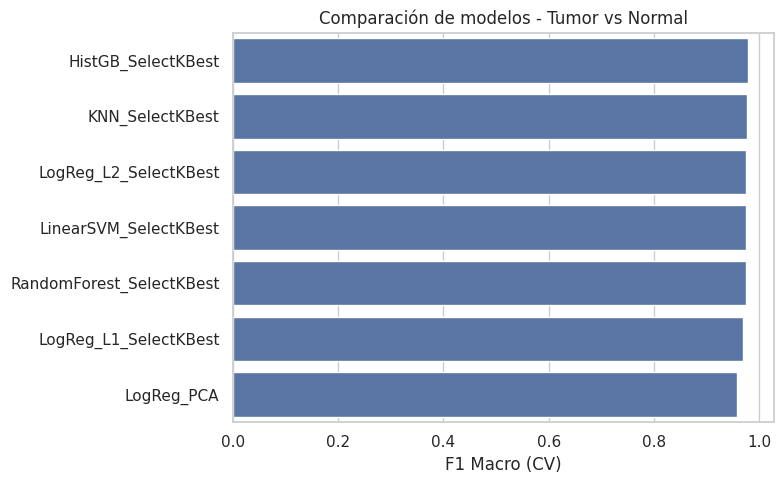

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_cv_m1,
    x="f1_macro_mean",
    y="modelo"
)

plt.title("Comparación de modelos - Tumor vs Normal")
plt.xlabel("F1 Macro (CV)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Resultados obtenidos**


Los resultados muestran un rendimiento muy elevado en todos los modelos, con valores de **F1-Macro superiores a 0.95** y **Balanced Accuracy cercanas al 97%**, lo que indica una alta capacidad para diferenciar tejido tumoral de tejido sano.

Aunque HistGradientBoosting obtuvo el mejor rendimiento durante la validación cruzada (F1-Macro = 0.979), la diferencia respecto a Regresión Logística fue inferior al 0.5%.

Dado que el objetivo del estudio incluye identificar genes relevantes asociados a la clasificación tumoral, se seleccionó Regresión Logística como modelo final por su mayor interpretabilidad, menor coste computacional y capacidad para analizar directamente la contribución de cada gen mediante sus coeficientes.

## 3.3 Optimización del modelo 1

Se ajusta el número de genes seleccionados (`k`) y la regularización (`C`) del modelo ganador Regresión Logística mediante `RandomizedSearchCV`.

La búsqueda se realizó utilizando validación cruzada estratificada y agrupada por paciente (`StratifiedGroupKFold`), empleando como métrica principal el **F1-Macro**.

Se exploraron los siguientes hiperparámetros:

- **Número de genes seleccionados (`k`)**: 500, 1000, 1500, 2000 y 3000.
- **Regularización (`C`)**: 0.01, 0.05, 0.1, 0.5, 1.0 y 2.0.

El objetivo fue identificar la combinación de parámetros que maximizara la capacidad de generalización del modelo manteniendo una adecuada selección de características en un problema de alta dimensionalidad.


In [7]:
# Optimización del modelo 1 (clasificación tumor vs normal)
pipe = Pipeline([
    ("var", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_dist = {
    "select__k": [500, 1000, 1500, 2000, 3000],
    "clf__C": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
}

search_model1 = RandomizedSearchCV(
    pipe, param_dist, n_iter=10, scoring="f1_macro", cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, refit=True)

t0 = time.time()
search_model1.fit(X_train, y1_train, groups=groups_train)
print(f"Mejor combinación modelo 1: {search_model1.best_params_} | f1_macro CV: {search_model1.best_score_:.4f} ({time.time()-t0:.1f}s)")

model1 = search_model1.best_estimator_


Mejor combinación modelo 1: {'select__k': 3000, 'clf__C': 0.05} | f1_macro CV: 0.9775 (99.0s)


**Resultados**

La mejor configuración obtenida fue:

- **Genes seleccionados (k):** 3000
- **Regularización (C):** 0.05
- **F1-Macro medio en validación cruzada:** 0.9775

Estos resultados muestran una excelente capacidad de generalización del modelo para distinguir entre muestras tumorales y normales.

## 3.4 Evaluación final sobre conjunto de prueba (Hold-out test)

Se realiza una evaluación final sobre el conjunto de prueba reservado previamente (*hold-out test*).

Este conjunto contiene muestras que no participaron en ninguna fase del entrenamiento ni de la optimización de hiperparámetros, por lo que permite obtener una estimación realista de la capacidad de generalización del modelo ante datos nuevos.

En esta etapa se generan las predicciones finales del clasificador, se calculan las métricas de rendimiento (Balanced Accuracy, F1-Macro, ROC-AUC y Cohen's Kappa), se analiza el rendimiento por clase mediante el *classification report* y se construye la matriz de confusión para identificar los tipos de errores cometidos por el modelo.

Finalmente, las métricas y visualizaciones obtenidas se almacenan para su posterior documentación e interpretación.



MODELO 1 - HOLD-OUT TEST -> balanced_accuracy=0.9888 | f1_macro=0.9743 | roc_auc=0.9971 | kappa=0.9487

              precision    recall  f1-score   support

      NORMAL      0.923     1.000     0.960        72
       TUMOR      1.000     0.978     0.989       268

    accuracy                          0.982       340
   macro avg      0.962     0.989     0.974       340
weighted avg      0.984     0.982     0.983       340



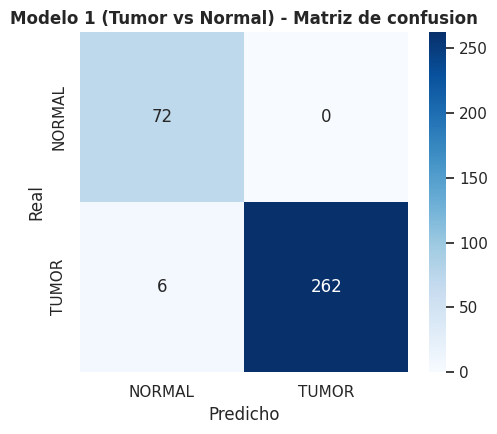

In [8]:
y1_pred = model1.predict(X_test)
y1_proba = model1.predict_proba(X_test)[:, list(model1.classes_).index("TUMOR")]

metrics_m1 = {
    "balanced_accuracy": balanced_accuracy_score(y1_test, y1_pred),
    "f1_macro": f1_score(y1_test, y1_pred, average="macro"),
    "roc_auc": roc_auc_score((y1_test == "TUMOR").astype(int), y1_proba),
    "kappa": cohen_kappa_score(y1_test, y1_pred),
}
print("MODELO 1 - HOLD-OUT TEST ->", " | ".join(f"{k}={v:.4f}" for k, v in metrics_m1.items()))
print()
print(classification_report(y1_test, y1_pred, digits=3))

labels_m1 = ["NORMAL", "TUMOR"]
cm1 = confusion_matrix(y1_test, y1_pred, labels=labels_m1)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_m1, yticklabels=labels_m1)
plt.title("Modelo 1 (Tumor vs Normal) - Matriz de confusion", fontweight="bold")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_modelo1.png"), dpi=130, bbox_inches="tight")
plt.show()

with open(os.path.join(OUTPUT_DIR, "final_metrics_modelo1.json"), "w") as f:
    json.dump(metrics_m1, f, indent=2)

**Resultados en el conjunto de prueba**

La evaluación final del modelo sobre el conjunto de prueba independiente mostró un rendimiento excelente. El clasificador alcanzó una Balanced Accuracy de 0.9888, un F1-Macro de 0.9743, un ROC-AUC de 0.9971 y un Cohen's Kappa de 0.9487.

La matriz de confusión revela que el modelo identificó correctamente las 72 muestras normales presentes en el conjunto de prueba, sin generar falsos positivos. Asimismo, clasificó correctamente 262 de las 268 muestras tumorales, produciendo únicamente 6 falsos negativos.

Estos resultados indican una elevada capacidad de discriminación entre tejido tumoral y tejido normal, demostrando que el modelo generaliza adecuadamente sobre pacientes no vistos durante el entrenamiento.


**Observación importante**
Aunque el modelo presenta un rendimiento excelente utilizando el umbral estándar de 0.5, en un contexto clínico podría explorarse la optimización del umbral de decisión. Como posible mejora futura, podría incorporarse una categoría de incertidumbre basada en las probabilidades predichas por el modelo. Las muestras con probabilidades cercanas al umbral de decisión podrían clasificarse como "indeterminadas", permitiendo derivarlas a análisis complementarios antes de emitir una decisión diagnóstica final.

##3.5 Interpretabilidad del Modelo 1

se analiza la interpretabilidad del modelo con el objetivo de identificar los genes que más contribuyen a la clasificación entre tejido tumoral y tejido normal.

Dado que el clasificador seleccionado es una Regresión Logística, cada gen recibe un coeficiente asociado que cuantifica su influencia en la predicción. La magnitud absoluta de dicho coeficiente refleja la importancia relativa del gen dentro del modelo, mientras que su signo indica hacia qué clase empuja la decisión.

Para facilitar la interpretación se seleccionaron los 25 genes con mayor valor absoluto del coeficiente tras el proceso de selección de características. Asimismo, se identificó la clase asociada a cada gen en función del signo de su coeficiente, permitiendo distinguir aquellos genes relacionados con muestras tumorales de aquellos asociados a tejido normal.

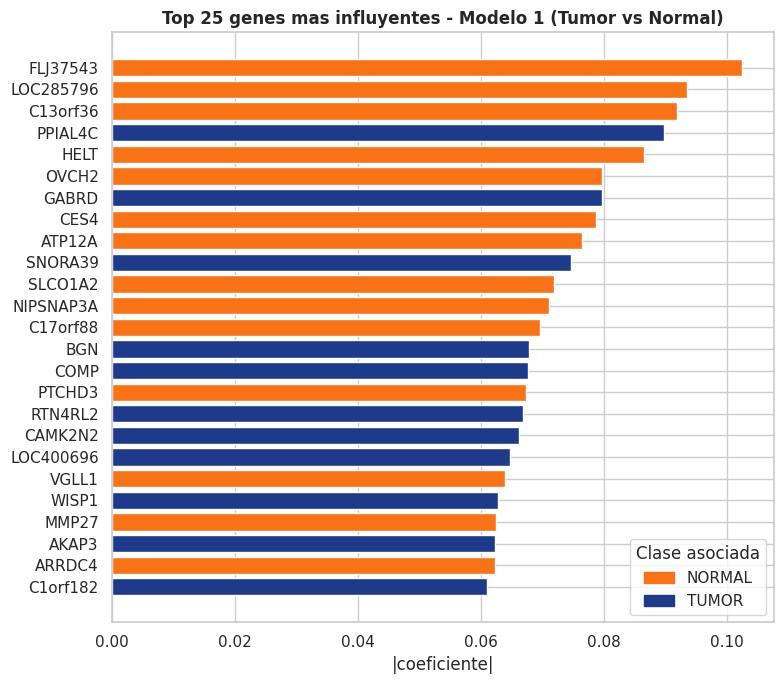

,gene,coeficiente,clase_asociada
0,FLJ37543,-0.102474,NORMAL
1,LOC285796,-0.093472,NORMAL
2,C13orf36,-0.091757,NORMAL
3,PPIAL4C,0.089660,TUMOR
4,HELT,-0.086502,NORMAL
5,OVCH2,-0.079591,NORMAL
6,GABRD,0.079578,TUMOR
7,CES4,-0.078622,NORMAL
8,ATP12A,-0.076350,NORMAL
9,SNORA39,0.074620,TUMOR


In [9]:
def top_genes_binary(model, gene_cols, topn=25):
    var_mask = model.named_steps["var"].get_support()
    genes_after_var = gene_cols[var_mask]
    select_mask = model.named_steps["select"].get_support()
    genes_selected = genes_after_var[select_mask]
    coef = model.named_steps["clf"].coef_[0]  # (n_features,) en binario
    order = np.argsort(-np.abs(coef))[:topn]
    clase_positiva = model.named_steps["clf"].classes_[1]
    clase_negativa = model.named_steps["clf"].classes_[0]
    return pd.DataFrame({
        "gene": genes_selected[order],
        "coeficiente": coef[order],
        "clase_asociada": np.where(coef[order] > 0, clase_positiva, clase_negativa),
    })

top_genes_m1 = top_genes_binary(model1, gene_cols, topn=25)
top_genes_m1.to_csv(os.path.join(OUTPUT_DIR, "top_genes_modelo1.csv"), index=False)
top_genes_m1.to_json(os.path.join(OUTPUT_DIR,"top_genes_modelo1.json"))

plot_df = top_genes_m1.reindex(top_genes_m1["coeficiente"].abs().sort_values().index)
colors = [palette_tipo.get(c, "#666666") for c in plot_df["clase_asociada"]]

plt.figure(figsize=(8, 7))
plt.barh(plot_df["gene"], plot_df["coeficiente"].abs(), color=colors)
plt.title("Top 25 genes mas influyentes - Modelo 1 (Tumor vs Normal)", fontweight="bold")
plt.xlabel("|coeficiente|")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette_tipo.values()]
plt.legend(handles, palette_tipo.keys(), title="Clase asociada", loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_genes_modelo1.png"), dpi=130, bbox_inches="tight")
plt.show()

top_genes_m1

**Resultados obtenidos**

La figura muestra los 25 genes con mayor contribución a la clasificación entre tejido tumoral y tejido normal. La importancia de cada gen se estimó mediante el valor absoluto de los coeficientes obtenidos por la Regresión Logística tras la selección de características.

Los genes representados mediante barras asociadas a la clase tumoral presentan coeficientes positivos, contribuyendo a aumentar la probabilidad de clasificar una muestra como tumor. Por el contrario, los genes asociados a la clase normal presentan coeficientes negativos y favorecen la clasificación como tejido sano.

La coexistencia de genes asociados a ambas clases indica que el modelo no basa sus predicciones en un único marcador, sino en patrones combinados de expresión génica, lo que resulta coherente con la naturaleza multifactorial de los procesos tumorales.

# 4. MODELO 2: Clasificación del tipo de cáncer

## 4.1 Filtrado de muestras tumorales

Una vez construido el clasificador binario capaz de distinguir entre tejido tumoral y tejido normal, se aborda una segunda tarea de mayor complejidad: la identificación del tipo específico de cáncer presente en cada muestra.

Para ello, se seleccionan exclusivamente las muestras etiquetadas como tumor y se excluyen todas las muestras normales del análisis. De esta forma, el modelo se centra únicamente en aprender las diferencias moleculares existentes entre los distintos tipos tumorales.

El problema se transforma así en una tarea de clasificación multiclase con cinco categorías:

- BRCA (Breast Invasive Carcinoma)
- COAD (Colon Adenocarcinoma)
- KIRC (Kidney Renal Clear Cell Carcinoma)
- LUAD (Lung Adenocarcinoma)
- PRAD (Prostate Adenocarcinoma)

Esta estrategia reproduce un escenario más realista desde el punto de vista clínico. Una vez confirmada la presencia de tejido tumoral, el siguiente paso consiste en determinar su origen mediante los patrones de expresión génica observados.

A continuación, se comparan distintos algoritmos de aprendizaje automático utilizando únicamente las muestras tumorales para evaluar su capacidad de discriminación entre las cinco cohortes de cáncer.

In [10]:
mask_train_tumor = binary_target[train_idx] == "TUMOR"
mask_test_tumor = binary_target[test_idx] == "TUMOR"

X2_train, y2_train = X_train[mask_train_tumor], multiclass_target[train_idx][mask_train_tumor]
X2_test, y2_test = X_test[mask_test_tumor], multiclass_target[test_idx][mask_test_tumor]
groups2_train = groups_train[mask_train_tumor]
groups2_test = groups_test[mask_test_tumor]

print("Train tumoral:", X2_train.shape, pd.Series(y2_train).value_counts().to_dict())
print("Test tumoral:", X2_test.shape, pd.Series(y2_test).value_counts().to_dict())

Train tumoral: (1076, 20531) {'BRCA': 366, 'KIRC': 220, 'LUAD': 197, 'PRAD': 154, 'COAD': 139}
Test tumoral: (268, 20531) {'BRCA': 82, 'KIRC': 68, 'PRAD': 54, 'LUAD': 39, 'COAD': 25}


## 4.2 Split por paciente Modelo 2


No se realizó una nueva partición de los datos para el Modelo 2. En su lugar, se reutilizó la división Train/Test definida previamente para el Modelo 1 mediante `GroupShuffleSplit`, garantizando que los pacientes del conjunto de prueba permanecieran completamente independientes del entrenamiento.

Posteriormente, se filtraron únicamente las muestras tumorales dentro de cada subconjunto, conservando la separación original por paciente.

Como verificación adicional, se comprobó que no existían pacientes compartidos entre los conjuntos de entrenamiento y prueba tras el filtrado, evitando cualquier posible fuga de información (*data leakage*).


In [11]:
assert set(np.unique(groups2_train)).isdisjoint(
    set(np.unique(groups2_test))
)

print("OK: sin pacientes compartidos entre train y test (Modelo 2)")
print("Train:", X2_train.shape, "Test:", X2_test.shape)

OK: sin pacientes compartidos entre train y test (Modelo 2)
Train: (1076, 20531) Test: (268, 20531)


##4.3 Comparación de modelos para el estudio multiclase

Una vez obtenido el conjunto de muestras tumorales, se compararon distintos algoritmos de aprendizaje automático para evaluar su capacidad de discriminación entre los cinco tipos de cáncer estudiados (BRCA, COAD, KIRC, LUAD y PRAD).

La evaluación se realizó exclusivamente sobre el conjunto de entrenamiento mediante validación cruzada estratificada y agrupada por paciente (`StratifiedGroupKFold`). Este procedimiento garantiza que las muestras pertenecientes a un mismo paciente permanezcan siempre dentro del mismo fold, evitando fugas de información y proporcionando una estimación más realista del rendimiento del modelo.

Se evaluaron varios clasificadores integrados en pipelines completos de preprocesado, incluyendo filtrado por varianza, estandarización, reducción de dimensionalidad y selección de características. Todos los pasos del preprocesamiento se ejecutaron dentro de cada fold de validación cruzada para evitar sesgos en la evaluación.

Para comparar los modelos se calcularon las siguientes métricas:

- **Balanced Accuracy**: evalúa el rendimiento medio entre todas las clases compensando posibles desbalances.
- **F1-Macro**: media no ponderada del F1-score de cada cohorte tumoral. Se utilizó como métrica principal de selección.
- **F1-Weighted**: F1-score ponderado según la frecuencia de cada clase.
- **ROC-AUC One-vs-Rest (OvR)**: capacidad global de discriminación del clasificador en el contexto multiclase.
- **Cohen's Kappa**: medida de concordancia entre predicciones y etiquetas reales corregida por azar.

Adicionalmente, se registró el tiempo de ejecución de cada modelo con el fin de valorar el compromiso entre rendimiento predictivo y coste computacional.

Los resultados obtenidos permitieron seleccionar el modelo con mejor capacidad de generalización para abordar la clasificación del subtipo tumoral.

In [12]:
def get_scoring_multiclass():
    return {
        "balanced_accuracy": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "roc_auc_ovr": "roc_auc_ovr",
        "kappa": make_scorer(cohen_kappa_score),
    }


cv2 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring2 = get_scoring_multiclass()

# mismos pipelines que en el modelo 1
pipelines2 = make_pipelines(
    k_best=1500,
    pca_components=50
)

rows = []

for name, pipe in pipelines2.items():

    t0 = time.time()

    cvres = cross_validate(
        pipe,
        X2_train,
        y2_train,
        groups=groups2_train,
        cv=cv2,
        scoring=scoring2,
        n_jobs=1
    )

    row = {
        "modelo": name,
        "tiempo_s": time.time() - t0
    }

    for m in scoring2:

        row[f"{m}_mean"] = np.mean(
            cvres[f"test_{m}"]
        )

        row[f"{m}_std"] = np.std(
            cvres[f"test_{m}"]
        )

    rows.append(row)

    print(
        f"{name}: "
        f"f1_macro={row['f1_macro_mean']:.3f} "
        f"balanced_acc={row['balanced_accuracy_mean']:.3f} "
        f"({row['tiempo_s']:.1f}s)"
    )

results_cv_m2 = (
    pd.DataFrame(rows)
      .sort_values("f1_macro_mean", ascending=False)
      .reset_index(drop=True)
)

results_cv_m2.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "results_modelo_2_cv.csv"
    ),
    index=False
)

results_cv_m2


LogReg_L2_SelectKBest: f1_macro=0.998 balanced_acc=0.998 (6.7s)
LogReg_L1_SelectKBest: f1_macro=0.997 balanced_acc=0.996 (9.4s)
LogReg_PCA: f1_macro=0.999 balanced_acc=0.998 (16.7s)
LinearSVM_SelectKBest: f1_macro=0.999 balanced_acc=0.999 (8.1s)
RandomForest_SelectKBest: f1_macro=0.999 balanced_acc=0.998 (36.4s)
HistGB_SelectKBest: f1_macro=0.998 balanced_acc=0.997 (285.4s)
KNN_SelectKBest: f1_macro=0.997 balanced_acc=0.996 (6.1s)


,modelo,tiempo_s,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,roc_auc_ovr_mean,roc_auc_ovr_std,kappa_mean,kappa_std
0,LinearSVM_SelectKBest,8.092251,0.999200,0.001600,0.999308,0.001384,0.999068,0.001863,1.000000,0.000000,0.998798,0.002404
1,RandomForest_SelectKBest,36.410850,0.998200,0.002227,0.998533,0.001801,0.998135,0.002284,1.000000,0.000000,0.997592,0.002950
2,LogReg_PCA,16.744257,0.998200,0.002227,0.998533,0.001801,0.998135,0.002284,1.000000,0.000000,0.997592,0.002950
3,LogReg_L2_SelectKBest,6.747039,0.997659,0.002045,0.997822,0.001784,0.997207,0.002280,1.000000,0.000000,0.996384,0.002952
4,HistGB_SelectKBest,285.391101,0.997174,0.003699,0.997723,0.003008,0.997213,0.003716,0.999986,0.000027,0.996397,0.004809
5,KNN_SelectKBest,6.067423,0.996174,0.004694,0.996946,0.003742,0.996270,0.004568,0.998958,0.001332,0.995179,0.005905
6,LogReg_L1_SelectKBest,9.363109,0.995962,0.004983,0.996621,0.004184,0.996278,0.004559,0.999994,0.000011,0.995181,0.005902


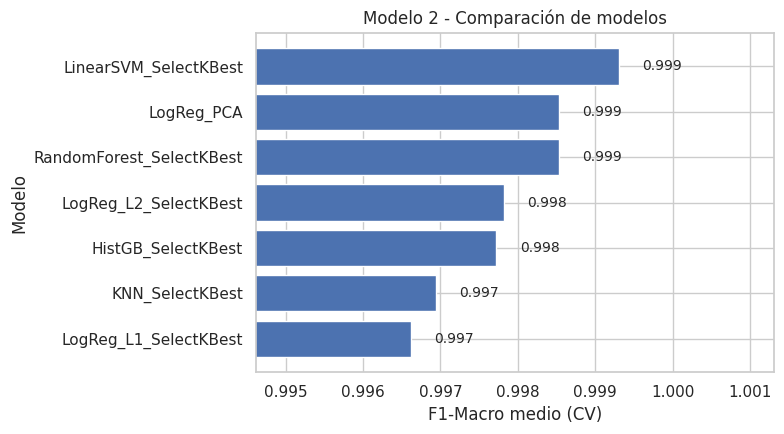

In [13]:
import matplotlib.pyplot as plt

plot_df = results_cv_m2.sort_values(
    "f1_macro_mean",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.barh(
    plot_df["modelo"],
    plot_df["f1_macro_mean"]
)

# Etiquetas
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.0003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

ax.set_xlabel("F1-Macro medio (CV)")
ax.set_ylabel("Modelo")
ax.set_title("Modelo 2 - Comparación de modelos")

# Zoom para apreciar diferencias
xmin = plot_df["f1_macro_mean"].min() - 0.002
xmax = plot_df["f1_macro_mean"].max() + 0.002

ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

**Resultados de la comparación de modelos**

La validación cruzada mostró un rendimiento muy elevado para todos los algoritmos evaluados, alcanzando valores de F1-Macro superiores al 0.99 en todos los casos. Estos resultados indican que los perfiles de expresión génica contienen una señal biológica muy discriminativa para diferenciar entre los cinco tipos tumorales analizados.

El modelo con mejor rendimiento fue LinearSVM, obteniendo un F1-Macro medio de 0.9993 y una Balanced Accuracy de 0.9992. Sin embargo, las diferencias observadas respecto a otros clasificadores fueron mínimas. En particular, la Regresión Logística con regularización L2 alcanzó un F1-Macro de 0.9978 y una Balanced Accuracy de 0.9977, situándose entre los modelos con mejor capacidad predictiva.

Dado que la diferencia de rendimiento entre ambos modelos fue inferior al 0.2%, se optó por seleccionar la Regresión Logística L2 como modelo final. Esta decisión se fundamenta en su mayor interpretabilidad, ya que permite analizar directamente la contribución de cada gen al proceso de clasificación mediante los coeficientes del modelo.

La elección de un modelo interpretable resulta especialmente relevante en un contexto biomédico, donde no solo interesa obtener predicciones precisas, sino también identificar patrones moleculares y posibles biomarcadores asociados a cada tipo de cáncer.


## 4.4 Optimización del modelo 2
Tras seleccionar la Regresión Logística con regularización L2 como clasificador final, se realizó un proceso de optimización de hiperparámetros con el objetivo de maximizar su capacidad de generalización.

La optimización se llevó a cabo mediante `RandomizedSearchCV`, utilizando validación cruzada estratificada y agrupada por paciente (`StratifiedGroupKFold`) para garantizar que las muestras pertenecientes a un mismo paciente permanecieran siempre dentro del mismo fold.

El pipeline optimizado incluyó las siguientes etapas:

1. Eliminación de variables con varianza nula (`VarianceThreshold`).
2. Estandarización de las variables (`StandardScaler`).
3. Selección de características mediante ANOVA (`SelectKBest`).
4. Clasificación mediante Regresión Logística con regularización L2.

Se evaluaron distintas combinaciones del número de genes seleccionados (`k = 500, 1000, 2000, 3000`) y del parámetro de regularización (`C = 0.01, 0.1, 0.5, 1.0, 2.0`), utilizando **F1-Macro** como métrica de optimización.

Finalmente, la combinación óptima fue utilizada para entrenar el modelo definitivo que posteriormente se evaluó sobre el conjunto de prueba independiente.


In [14]:
pipe2 = Pipeline([
    ("var", VarianceThreshold(threshold=0.0)),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(f_classif)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_dist2 = {
    "select__k": [500, 1000, 2000, 3000],
    "clf__C": [0.01, 0.1, 0.5, 1.0, 2.0],
}

search2 = RandomizedSearchCV(
    pipe2, param_dist2, n_iter=10, scoring="f1_macro", cv=cv2,
    random_state=RANDOM_STATE, n_jobs=1, refit=True)

t0 = time.time()
search2.fit(X2_train, y2_train, groups=groups2_train)
print(f"Mejor combinacion: {search2.best_params_} | f1_macro CV: {search2.best_score_:.4f} "
      f"({time.time()-t0:.1f}s)")

model2 = search2.best_estimator_

Mejor combinacion: {'select__k': 500, 'clf__C': 0.01} | f1_macro CV: 0.9993 (74.1s)


**Resultados de la optimización**

La optimización mediante `RandomizedSearchCV` identificó como mejor configuración una selección de **500 genes** (`k = 500`) y una regularización fuerte (**C = 0.01**).

La mejor combinación alcanzó un **F1-Macro medio de 0.9993** durante la validación cruzada, igualando el rendimiento de los modelos más competitivos evaluados previamente.

Este resultado indica que una representación relativamente reducida del espacio génico es suficiente para discriminar con gran precisión entre las cinco cohortes tumorales estudiadas.

La configuración seleccionada fue utilizada para entrenar el modelo final (`best_model2`), que posteriormente se evaluó sobre el conjunto de prueba independiente.

## 4.5 Evaluación final del modelo en datos no vistos

Tras completar el proceso de selección y optimización de hiperparámetros, el modelo final se evaluó sobre el conjunto de prueba independiente compuesto por pacientes no utilizados durante el entrenamiento.

El objetivo de esta evaluación es estimar la capacidad real de generalización del clasificador para identificar el tipo de cáncer a partir de perfiles de expresión génica en muestras completamente nuevas.


MODELO 2 - HOLD-OUT TEST -> balanced_accuracy=1.0000 | f1_macro=1.0000 | f1_weighted=1.0000 | roc_auc_ovr=1.0000 | kappa=1.0000

              precision    recall  f1-score   support

        BRCA      1.000     1.000     1.000        82
        COAD      1.000     1.000     1.000        25
        KIRC      1.000     1.000     1.000        68
        LUAD      1.000     1.000     1.000        39
        PRAD      1.000     1.000     1.000        54

    accuracy                          1.000       268
   macro avg      1.000     1.000     1.000       268
weighted avg      1.000     1.000     1.000       268



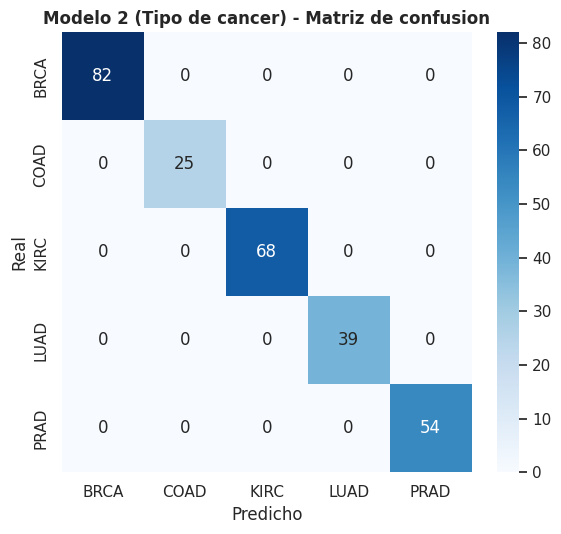

In [15]:
y2_pred = model2.predict(X2_test)
y2_proba = model2.predict_proba(X2_test)

metrics_m2 = {
    "balanced_accuracy": balanced_accuracy_score(y2_test, y2_pred),
    "f1_macro": f1_score(y2_test, y2_pred, average="macro"),
    "f1_weighted": f1_score(y2_test, y2_pred, average="weighted"),
    "roc_auc_ovr": roc_auc_score(y2_test, y2_proba, multi_class="ovr"),
    "kappa": cohen_kappa_score(y2_test, y2_pred),
}
print("MODELO 2 - HOLD-OUT TEST ->", " | ".join(f"{k}={v:.4f}" for k, v in metrics_m2.items()))
print()
print(classification_report(y2_test, y2_pred, digits=3))

labels_m2 = sorted(np.unique(cohorte))
cm2 = confusion_matrix(y2_test, y2_pred, labels=labels_m2)

plt.figure(figsize=(6, 5.5))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_m2, yticklabels=labels_m2)
plt.title("Modelo 2 (Tipo de cancer) - Matriz de confusion", fontweight="bold")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_modelo2.png"), dpi=130, bbox_inches="tight")
plt.show()

with open(os.path.join(OUTPUT_DIR, "final_metrics_modelo2.json"), "w") as f:
    json.dump(metrics_m2, f, indent=2)


**Resultados en el conjunto de prueba**

La evaluación final del modelo sobre el conjunto de prueba independiente mostró un rendimiento perfecto en todas las métricas analizadas. El clasificador alcanzó una Balanced Accuracy de 1.000, un F1-Macro de 1.000, un F1-Weighted de 1.000, un ROC-AUC OvR de 1.000 y un Cohen's Kappa de 1.000.

Asimismo, el informe de clasificación muestra valores de precisión, sensibilidad (*recall*) y F1-score iguales a 1.000 para las cinco cohortes tumorales analizadas (BRCA, COAD, KIRC, LUAD y PRAD).

La matriz de confusión confirma estos resultados, observándose una clasificación correcta de las 268 muestras del conjunto de prueba sin producir ningún error de asignación entre cohortes. Todas las observaciones se sitúan sobre la diagonal principal de la matriz, indicando una separación completa entre las clases evaluadas.

## 4.6 Interpretabilidad del modelo

Además de evaluar el rendimiento predictivo, se analizó la interpretabilidad del modelo con el objetivo de identificar los genes que más contribuyen a la discriminación entre los distintos tipos de cáncer.

Dado que el modelo seleccionado es una Regresión Logística multiclase, cada gen recibe un coeficiente asociado para cada una de las cohortes tumorales. La magnitud de estos coeficientes permite estimar la relevancia de cada gen en el proceso de clasificación.

Para obtener una medida global de importancia, se calculó la suma de los valores absolutos de los coeficientes del modelo para cada gen a través de todas las clases. Posteriormente, se seleccionaron los 25 genes con mayor importancia global.

Además, para facilitar la interpretación biológica, cada gen se asoció a la cohorte tumoral en la que presentó el coeficiente absoluto más elevado, permitiendo identificar aquellos genes con una mayor contribución relativa a cada tipo de cáncer.

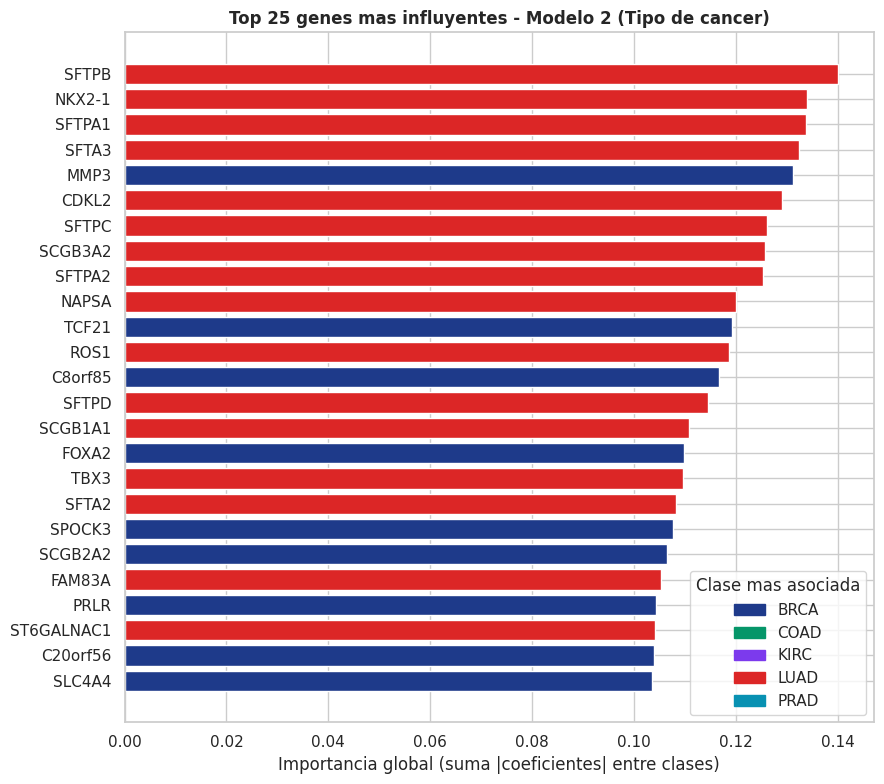

,gene,importancia_global,clase_mas_asociada
0,SFTPB,0.140085,LUAD
1,NKX2-1,0.133854,LUAD
2,SFTPA1,0.133754,LUAD
3,SFTA3,0.132320,LUAD
4,MMP3,0.131199,BRCA
5,CDKL2,0.128972,LUAD
6,SFTPC,0.126146,LUAD
7,SCGB3A2,0.125637,LUAD
8,SFTPA2,0.125337,LUAD
9,NAPSA,0.120091,LUAD


In [16]:
def top_genes_multiclass(model, gene_cols, topn=25):
    var_mask = model.named_steps["var"].get_support()
    genes_after_var = gene_cols[var_mask]
    select_mask = model.named_steps["select"].get_support()
    genes_selected = genes_after_var[select_mask]
    coefs = model.named_steps["clf"].coef_  # (n_clases, n_features)
    importancia = np.abs(coefs).sum(axis=0)
    order = np.argsort(-importancia)[:topn]
    classes = model.named_steps["clf"].classes_
    top_class_idx = np.argmax(np.abs(coefs[:, order]), axis=0)
    return pd.DataFrame({
        "gene": genes_selected[order],
        "importancia_global": importancia[order],
        "clase_mas_asociada": classes[top_class_idx],
    })

top_genes_m2 = top_genes_multiclass(model2, gene_cols, topn=25)
top_genes_m2.to_csv(os.path.join(OUTPUT_DIR, "top_genes_modelo2.csv"), index=False)
top_genes_m2.to_json(
    os.path.join(OUTPUT_DIR, "top_genes_modelo2.json"),
    orient="records",
    indent=4
)
plot_df = top_genes_m2.sort_values("importancia_global")
colors = [palette_cohorte.get(c, "#666666") for c in plot_df["clase_mas_asociada"]]

plt.figure(figsize=(9, 8))
plt.barh(plot_df["gene"], plot_df["importancia_global"], color=colors)
plt.title("Top 25 genes mas influyentes - Modelo 2 (Tipo de cancer)", fontweight="bold")
plt.xlabel("Importancia global (suma |coeficientes| entre clases)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette_cohorte.values()]
plt.legend(handles, palette_cohorte.keys(), title="Clase mas asociada", loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_genes_modelo2.png"), dpi=130, bbox_inches="tight")
plt.show()

top_genes_m2


**Resultados de la distribucion de los genes mas influyente**

El análisis de interpretabilidad identificó los 25 genes con mayor importancia global dentro de la Regresión Logística multiclase.

La distribución de estos genes entre las distintas cohortes no fue homogénea. La mayoría de los genes más relevantes se asociaron a los cánceres de pulmón (LUAD) y mama (BRCA):


Se observa que el 68% de los genes más importantes se encuentran asociados a LUAD, mientras que el 32% restante se relaciona con BRCA.

Estos resultados sugieren que las firmas transcriptómicas de LUAD y BRCA contienen marcadores especialmente discriminativos dentro del conjunto de datos, siendo capaces de separar estas cohortes del resto con gran facilidad.

Por el contrario, entre los 25 genes más influyentes no aparecen genes cuya máxima contribución se asocie a COAD, KIRC o PRAD. Esto no implica que dichas cohortes carezcan de genes relevantes para la clasificación, sino que los genes con mayor peso global del modelo están dominados por señales moleculares características de LUAD y BRCA.


# 5. Visualización global del espacio transcriptómico

Aunque los modelos de clasificación alcanzaron un rendimiento muy elevado, resulta útil visualizar la estructura global de los datos para comprender por qué la discriminación entre cohortes tumorales es posible.

Para ello se aplicó un Análisis de Componentes Principales (PCA) sobre la matriz de expresión génica completa, proyectando las muestras en un espacio tridimensional definido por las tres componentes principales.

Esta representación permite observar cómo se distribuyen las muestras en función de sus patrones transcriptómicos y evaluar visualmente el grado de separación existente entre los distintos tejidos y tipos de cáncer.

In [18]:
from sklearn.decomposition import PCA
import pandas as pd
import plotly.express as px

# Create meta DataFrame (if not already defined)
if 'meta' not in locals() and 'meta' not in globals():
    meta = df[meta_cols] # Assuming df and meta_cols are defined in previous cells

# PCA 3D
pca = PCA(n_components=3, random_state=42)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "cohorte": meta["cohorte"].values,
    "tipo": meta["tipo"].values
})

# Crear etiqueta conjunta
pca_df["grupo"] = pca_df["tipo"] + "_" + pca_df["cohorte"]

fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="grupo",
    opacity=0.8,
    title="Espacio transcriptómico global (PCA 3D)"
)

fig.update_traces(marker=dict(size=4))

fig.show()

## 6.Test de permutación


Con el objetivo de verificar que el rendimiento observado no se debía al azar, se realizó un test de permutación utilizando la misma estrategia de validación cruzada empleada durante el entrenamiento.

Este procedimiento consiste en mezclar aleatoriamente las etiquetas de las muestras y recalcular el rendimiento del modelo múltiples veces. Si el clasificador está aprendiendo una señal biológica real, su rendimiento sobre los datos originales debe ser significativamente superior al obtenido con etiquetas aleatorias.

In [19]:
# es la pieza que confirma con evidencia (no con intuición) que el modelo no está haciendo trampa.
from sklearn.model_selection import permutation_test_score

score, perm_scores, pvalue = permutation_test_score(
    model1, X_train, y1_train, groups=groups_train,
    cv=cv, scoring="f1_macro", n_permutations=100, n_jobs=-1, random_state=42
)
print(f"Score real: {score:.3f} | Score con etiquetas al azar: {perm_scores.mean():.3f} | p-valor: {pvalue:.4f}")

Score real: 0.978 | Score con etiquetas al azar: 0.636 | p-valor: 0.0099


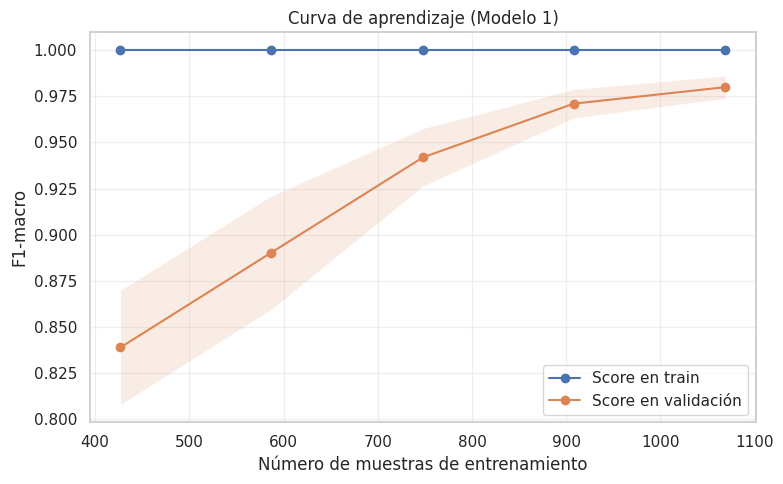

In [22]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=model1,              # Usamos el modelo binario (model1)
    X=X_train, y=y1_train, # Datos de entrenamiento para model1
    groups=groups_train,                # Agrupación por paciente para model1
    cv=cv,                               # el mismo StratifiedGroupKFold que ya usas
    scoring="f1_macro", # Usamos f1_macro como en la optimización
    train_sizes=np.linspace(0.4, 1.0, 5),
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", label="Score en train")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

plt.plot(train_sizes, val_mean, "o-", label="Score en validación")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("F1-macro")
plt.title("Curva de aprendizaje (Modelo 1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##6. Guardado de modelos
Se guardan ambos pipelines completos (preprocesado + modelo entrenado) con joblib, listos para usarse en producción: primero el Modelo 1 sobre cualquier muestra nueva, y el Modelo 2 únicamente sobre las que el Modelo 1 clasifique como TUMOR.

Posteriormente, todos los archivos generados durante el estudio se comprimieron automáticamente en un archivo ZIP para facilitar su descarga y conservación.


In [25]:
import zipfile

joblib.dump(model1, os.path.join(OUTPUT_DIR, "modelo1_tumor_vs_normal.joblib"))
joblib.dump(model2, os.path.join(OUTPUT_DIR, "modelo2_tipo_cancer.joblib"))

print("Archivos generados en", os.path.abspath(OUTPUT_DIR), ":")

zip_file_path = os.path.join(OUTPUT_DIR, "outputs_estudio.zip")
with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in sorted(os.listdir(OUTPUT_DIR)):
        file_path = os.path.join(OUTPUT_DIR, f)
        if os.path.isfile(file_path):
            zipf.write(file_path, arcname=f)
            print(f" - {f}")

try:
    from google.colab import files
    print("\nDescargando archivo ZIP...")
    files.download(zip_file_path)
    print("Archivo ZIP descargado.")
except ImportError:
    print("\nNo estás en Google Colab: los archivos ya están guardados en la carpeta 'outputs_estudio_c/' como archivo ZIP.")

Archivos generados en /content/outputs_modelado_ml :
 - final_metrics_modelo1.json
 - final_metrics_modelo2.json
 - matriz_confusion_modelo1.png
 - matriz_confusion_modelo2.png
 - modelo1_tumor_vs_normal.joblib
 - modelo2_tipo_cancer.joblib


OSError: [Errno 28] No space left on device

## 7. Conclusiones finales


En este estudio se desarrolló una estrategia jerárquica basada en aprendizaje automático para la clasificación de muestras de expresión génica, abordando dos tareas: la detección de tejido tumoral y la identificación del tipo específico de cáncer.

El **Modelo 1 (Tumor vs Normal)** obtuvo un excelente rendimiento sobre pacientes no vistos durante el entrenamiento, alcanzando un **F1-Macro de 0.974** y una **Balanced Accuracy de 0.989**, demostrando una elevada capacidad de generalización.

Por su parte, el **Modelo 2 (clasificación del tipo de cáncer)** alcanzó una clasificación perfecta en el conjunto de prueba independiente (**F1-Macro = 1.000**), evidenciando que las cohortes tumorales analizadas presentan firmas transcriptómicas altamente diferenciadas.

El análisis de interpretabilidad permitió identificar los genes con mayor influencia en las predicciones, aportando información biológicamente relevante y aumentando la transparencia de los modelos desarrollados.

### Hallazgos más relevantes

Uno de los hallazgos más interesantes del estudio fue observar que ambos problemas presentan niveles de complejidad biológica diferentes.

Para diferenciar tejido tumoral de tejido normal, el modelo necesitó aproximadamente **3.000 genes** para alcanzar su rendimiento óptimo.

Sin embargo, la clasificación de los distintos tipos tumorales alcanzó un rendimiento perfecto utilizando únicamente **500 genes seleccionados**.

Este resultado sugiere que la transformación de tejido sano a tejido tumoral implica alteraciones distribuidas a lo largo de una gran parte del transcriptoma, mientras que la diferenciación entre tipos de cáncer depende de firmas moleculares más específicas y características de cada cohorte.

Otro aspecto destacable fue la capacidad de los modelos para identificar genes especialmente influyentes en las predicciones, proporcionando información potencialmente útil para la exploración biológica de los mecanismos que distinguen cada tipo tumoral.

---

### Interpretación biológica

La visualización tridimensional del espacio transcriptómico permitió observar una clara organización natural de las muestras.

Las muestras normales aparecieron separadas de las tumorales, mientras que los distintos tipos de cáncer formaron agrupaciones diferenciadas dentro del espacio de expresión génica.

Esta estructura explica, en gran medida, el elevado rendimiento alcanzado por los modelos desarrollados y confirma la existencia de firmas transcriptómicas altamente características para cada cohorte tumoral.

La coherencia entre la visualización de los datos, las métricas obtenidas y los genes identificados refuerza la validez biológica de los resultados.

---

### Aportación del estudio

Más allá del rendimiento predictivo, este trabajo demuestra que modelos interpretables pueden extraer información relevante a partir de datos ómicos de alta dimensionalidad.

La combinación de:

- Selección de características.
- Validación rigurosa por paciente.
- Interpretabilidad basada en coeficientes.
- Visualización transcriptómica.

permitió construir un sistema robusto y fácilmente interpretable, manteniendo al mismo tiempo un rendimiento excelente.

Este enfoque resulta especialmente valioso en aplicaciones biomédicas, donde comprender las razones detrás de una predicción es tan importante como la propia predicción.

---

### Limitaciones y trabajo futuro

A pesar de los excelentes resultados obtenidos, existen varias limitaciones que deben tenerse en cuenta.

Todos los modelos fueron desarrollados y evaluados utilizando datos procedentes del mismo conjunto de estudio. Aunque se emplearon estrategias estrictas para evitar fugas de información mediante separación por paciente y validación cruzada agrupada, sería recomendable validar el sistema sobre cohortes externas independientes.

Como posibles líneas futuras destacan:

- Validación en datasets externos.
- Incorporación de nuevos tipos tumorales.
- Comparación con modelos de Deep Learning.
- Integración de variables clínicas junto a la expresión génica.
- Análisis biológico detallado de los genes más relevantes identificados por los modelos.

---